<a href="https://colab.research.google.com/github/chennaichun/AI_Design_NCKU_Lecture/blob/main/Computer_Vision_Part2_VLM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Google Colab 硬體加速器選擇指南

這份指南說明如何在 Google Colab 的「筆記本設定」中，根據專案需求選擇最合適的硬體。

---

## GPU 系列 (繪圖處理器)
最適合：深度學習、PyTorch/TensorFlow 模型訓練、生成式 AI。

| 型號 | 定位 | 適用場景 |
| :--- | :--- | :--- |
| **H100 GPU** | 當前頂規 | 訓練大型語言模型 (LLM)、大規模生成式 AI、追求極致運算速度。 |
| **A100 GPU** | 專業旗艦 | 需要高顯存 (VRAM) 的任務，處理超大型數據集。 |
| **L4 / G4 GPU** | 效能平衡 | 模型推論 (Inference)、中型模型訓練，性價比高。 |
| **T4 GPU** | 入門首選 | 初學者練習、小型實驗、基礎影像辨識。 |

---

## TPU 系列 (張量處理器)
最適合：Google 生態系 (JAX/TensorFlow)、極大規模矩陣運算。

* **v6e-1 / v5e-1 TPU**：Google 專為機器學習打造的加速專用集成電路。
* **優點**：在處理數十億參數的超大型運算時，平行處理能力極強。
* **注意**：程式碼通常需要針對 TPU 進行優化，適合進階開發者。

---

## 其他關鍵設定

### 1. 執行階段類型 (Runtime Type)
* 預設通常為 Python 3，這是目前絕大多數 AI 專案使用的開發環境。

### 2. 大量 RAM (High RAM)
* 使用時機：當處理的原始資料量超過系統預設記憶體，導致程式崩潰 (Crash) 時，應啟用此選項。

### 3. CPU (無加速)
* 使用時機：僅進行簡單的數據爬蟲、純文字處理或基礎數學運算，不涉及模型訓練時。

---

## 快速決策表

| 開發目標 | 推薦硬體 |
| :--- | :--- |
| 基礎 Python 學習或 AI 初探 | T4 GPU |
| 運行 Stable Diffusion 或 Llama 3 | A100 或 H100 |
| 部署輕量化 AI 服務 | L4 GPU |
| 程式因記憶體不足而中斷 | 開啟 大量 RAM |

---

## 檢查硬體狀態 (Python 代碼)
在 Colab 儲存格執行以下代碼，確認 GPU 是否運作正常：

```python
import torch
if torch.cuda.is_available():
    print(f"成功偵測到 GPU: {torch.cuda.get_device_name(0)}")
else:
    print("未偵測到 GPU，目前使用的是 CPU 模式。")

# AI for Video Understanding: From Content Moderation to Summarization

## Introduction

The rapid growth of video content has created a need for advanced systems to process and understand this complex data.  
**Video understanding** is a critical field in AI, where the goal is to enable machines to:
- Comprehend visual scenes  
- Analyze temporal events  
- Interact with video content  
— much like humans

---

## Video Understanding Overview

<p align="center">
  <img src="https://learnopencv.com/wp-content/uploads/2025/08/featured_image_video_understanding.gif" width="700"><br>
  <em>Multimodal Video Understanding Pipeline</em>
</p>

---

## GroundingDINO + SAM Pipeline

This notebook first introduces a foundational visual pipeline for video analysis:

- Video → Frames  
- Object Detection (text-based, GroundingDINO)  
- Segmentation (SAM)  
- Basic visual understanding pipeline  

This stage focuses on extracting structured visual information from raw video data.

---

## What We Will Build

Building on the visual pipeline, we design and analyze two practical multimodal systems:

### Video Content Moderation
- Model: CLIP + Gemini  
- Goal:
  - Detect unsafe or inappropriate content  
  - Ensure videos comply with platform policies  

---

### Video Summarization
- Model: Qwen2.5-VL  
- Goal:
  - Extract key information from videos  
  - Generate concise and meaningful summaries  

---

## End-to-End Pipeline

Finally, we integrate these components into a complete real-world workflow:

```text
Video Input
   ↓
Content Moderation (Safety Check)
   ↓
Video Summarization
   ↓
Final Output (Safe + Concise Content)

## Table of Contents

1. [Introduction](#introduction)  
2. [Video Understanding Overview](#video-understanding-overview)  
3. [GroundingDINO + SAM Pipeline](#groundingdino--sam-pipeline)  
4. [Model Foundations](#model-foundations)  
   - [CLIP](#clip-contrastive-languageimage-pretraining)  
   - [Gemini](#gemini)  
   - [Qwen2.5-VL](#qwen25-vl)  
5. [Part 1: Video Content Moderation](#part-1-video-content-moderation-with-clip-and-gemini)  
6. [Part 2: Video Summarization](#part-2-video-summarization-with-qwen25-vl)  
7. [Part 3: Combining Moderation + Summarization](#part-3-combining-moderation--summarization)  
8. [Results](#results)  


### 在 Colab Secrets 中設定 Hugging Face Token

1.  **取得 Hugging Face Token：**
    *   前往 [Hugging Face 網站](https://huggingface.co/settings/tokens)。
    *   登入您的帳戶（如果尚未登入）。
    *   點擊頁面左側的「Access Tokens」。
    *   點擊「New token」，為其命名（例如：`colab-hf-token`），並設定權限（建議選擇 `write` 或 `read`，視您的需求而定）。
    *   建立後，複製您的 token。

2.  **在 Colab 中設定 Secret：**
    *   在 Colab 介面的左側邊欄中，找到「🔑」圖示（或「Secrets」圖示），點擊它。
    *   點擊「Add new secret」。
    *   在「Name」欄位中輸入 `HF_TOKEN`（這是一個慣例名稱，確保您的程式碼可以找到它）。
    *   在「Value」欄位中貼上您剛剛從 Hugging Face 複製的 token。
    *   勾選「Notebook access」，確保您的 Colab Notebook 可以存取此 secret。
    *   點擊「Save secret」。

設定完成後，您的 Colab Notebook 就可以透過 `userdata.get('HF_TOKEN')` 取得此 token，用於驗證 Hugging Face 模型存取。


# Google Colab 硬體加速器選擇指南

這份指南說明如何在 Google Colab 的「筆記本設定」中，根據專案需求選擇最合適的硬體。

---

## GPU 系列 (繪圖處理器)

最適合：深度學習、PyTorch/TensorFlow 模型訓練、生成式 AI。

| 型號 | 定位 | 適用場景 |
| :--- | :--- | :--- |
| **H100 GPU** | 當前頂規 | 訓練大型語言模型 (LLM)、大規模生成式 AI、追求極致運算速度。 |
| **A100 GPU** | 專業旗艦 | 需要高顯存 (VRAM) 的任務，處理超大型數據集。 |
| **L4 / G4 GPU** | 效能平衡 | 模型推論 (Inference)、中型模型訓練，性價比高。 |
| **T4 GPU** | 入門首選 | 初學者練習、小型實驗、基礎影像辨識。 |

---

## TPU 系列 (張量處理器)

最適合：Google 生態系 (JAX/TensorFlow)、極大規模矩陣運算。

* **v6e-1 / v5e-1 TPU**：Google 專為機器學習打造的加速專用集成電路。
* **優點**：在處理數十億參數的超大型運算時，平行處理能力極強。
* **注意**：程式碼通常需要針對 TPU 進行優化，適合進階開發者。

---

## 其他關鍵設定

### 1. 執行階段類型 (Runtime Type)
* 預設通常為 Python 3，這是目前絕大多數 AI 專案使用的開發環境。

### 2. 大量 RAM (High RAM)
* 使用時機：當處理的原始資料量超過系統預設記憶體，導致程式崩潰 (Crash) 時，應啟用此選項。

### 3. CPU (無加速)
* 使用時機：僅進行簡單的數據爬蟲、純文字處理或基礎數學運算，不涉及模型訓練時。

---

## 快速決策表

| 開發目標 | 推薦硬體 |
| :--- | :--- |
| 基礎 Python 學習或 AI 初探 | T4 GPU |
| 運行 Stable Diffusion 或 Llama 3 | A100 或 H100 |
| 部署輕量化 AI 服務 | L4 GPU |
| 程式因記憶體不足而中斷 | 開啟 大量 RAM |

---

## 檢查硬體狀態 (Python 代碼)

在 Colab 儲存格執行以下代碼，確認 GPU 是否運作正常：

```python
import torch
if torch.cuda.is_available():
    print(f"成功偵測到 GPU: {torch.cuda.get_device_name(0)}")
else:
    print("未偵測到 GPU，目前使用的是 CPU 模式。")
```


## Model Foundations: CLIP, Gemini, and Qwen

This section introduces the core models used in our pipeline, covering three key capabilities:
- Detection (CLIP)  
- Explanation (Gemini)  
- Summarization (Qwen2.5-VL)  

---

### CLIP (Contrastive Language–Image Pretraining)

<p align="center">
  <img src="https://learnopencv.com/wp-content/uploads/2025/08/CLIP-arch.png" width="700"><br>
  <em>CLIP architecture: aligning image and text embeddings</em>
</p>

CLIP, introduced by OpenAI, is trained on 400 million image–text pairs. It learns to align images and text into a shared embedding space:

- If an image and caption match, their embeddings are close  
- If they do not match, their embeddings are pushed apart  

This enables **zero-shot classification**, where natural language prompts can be used directly without task-specific training.

**Example prompt:**
- "this image contains nudity"  
- "this image is safe"  

CLIP computes similarity between the image and these prompts to determine the most relevant label.

#### Strengths for Moderation

- Flexible: categories can be added or removed via prompts  
- Generalizable: adapts to new scenarios without retraining  
- Efficient: fast inference for large-scale filtering  

---

### Gemini

Gemini is Google’s family of large multimodal models.

In this pipeline, Gemini is used not for classification, but for **explanation and reasoning**.

It takes flagged frames as input and produces:
- Natural language explanations  
- Context-aware interpretations  
- Justifications for moderation decisions  

This improves:
- Transparency  
- Auditability  
- Regulatory compliance  

---

### Qwen2.5-VL

<p align="center">
  <img src="https://learnopencv.com/wp-content/uploads/2025/08/qwen2.5vl_arc-1-1024x671.jpeg" width="700"><br>
  <em>Qwen2.5-VL multimodal architecture</em>
</p>

Qwen2.5-VL, developed by Alibaba, is a vision-language model designed for multimodal understanding.

Unlike CLIP, which focuses on alignment, Qwen2.5-VL is a **generative model**.  
It takes video (via sampled frames) as input and produces structured textual outputs.

#### Key Capabilities

- Processes video through sampled frames  
- Follows instructions for controllable outputs  
- Generates:
  - Bullet-point summaries  
  - Paragraph-level descriptions  

---

### Summary

Together, these models form a complementary pipeline:

```text
Detect (CLIP) → Explain (Gemini) → Summarize (Qwen2.5-VL)




## Part 1: Video Content Moderation with CLIP and Gemini

We begin with the moderation pipeline.  
This script performs three main steps:

1. Extract frames from a video  
2. Classify each frame using CLIP  
3. Generate explanations for unsafe content using Gemini  

---

### Imports

In this section, we import the required libraries for:
- Video processing  
- Model inference  
- Data handling  

In [6]:
# =========================
# Imports for Part 1 (Moderation)
# =========================
import cv2
import torch
import numpy as np
from PIL import Image

from transformers import (
    CLIPProcessor,
    CLIPModel,
)

# =========================
# Device
# =========================
device = "cuda" if torch.cuda.is_available() else "cpu"

# =========================
# Load CLIP
# =========================
clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

labels = ["normal", "nudity", "sensual", "violent"]

text_inputs = [
    "this image is normal",
    "this image contains nudity",
    "this image contains sensual content",
    "this image contains violence"
]

text_batch = clip_processor(text=text_inputs, return_tensors="pt", padding=True).to(device)

with torch.no_grad():
    text_features = clip_model.get_text_features(**text_batch)
    if not isinstance(text_features, torch.Tensor):
        text_features = text_features.pooler_output
    text_features = text_features / text_features.norm(dim=-1, keepdim=True)

# =========================
# Frame Extraction
# =========================
def extract_frames(video_path, sample_rate=15):
    cap = cv2.VideoCapture(video_path)
    frames = []
    idx = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        if idx % sample_rate == 0:
            rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frames.append((idx, Image.fromarray(rgb)))

        idx += 1

    cap.release()
    return frames

# =========================
# CLIP Classification
# =========================
def classify_frame(frame):
    inputs = clip_processor(images=frame, return_tensors="pt").to(device)

    with torch.no_grad():
        image_features = clip_model.get_image_features(**inputs)
        if not isinstance(image_features, torch.Tensor):
            image_features = image_features.pooler_output
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)

    similarity = image_features @ text_features.T
    probs = similarity.softmax(dim=-1)

    confidence, pred = probs.max(dim=-1)
    return labels[pred.item()], confidence.item()

# =========================
# Local Explanation (NO API)
# =========================
def generate_explanation(flagged):
    explanations = []

    for f in flagged:
        if f["classification"] == "nudity":
            explanations.append(f"Frame {f['frame_id']} may contain nudity.")
        elif f["classification"] == "sensual":
            explanations.append(f"Frame {f['frame_id']} contains suggestive content.")
        elif f["classification"] == "violent":
            explanations.append(f"Frame {f['frame_id']} may contain violent activity.")

    return " ".join(explanations[:3]) if explanations else "No issues detected."

# =========================
# Moderation
# =========================
def moderate_video(video_path):
    frames = extract_frames(video_path)
    flagged = []

    for idx, img in frames:
        label, conf = classify_frame(img)

        if label != "normal" and conf > 0.5:
            flagged.append({
                "frame_id": idx,
                "classification": label,
                "confidence": round(conf, 3)
            })

    percent = (len(flagged) / len(frames)) * 100 if frames else 0

    return {
        "flagged": flagged,
        "percentage": round(percent, 2),
        "explanation": generate_explanation(flagged)
    }

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [7]:
!pip install av --quiet
!pip install qwen-vl-utils

## Part 2: Video Summarization with Qwen2.5-VL

In [8]:
import os
from google.colab import userdata
import json
from pathlib import Path
from transformers import AutoProcessor, Qwen2_5_VLForConditionalGeneration
from qwen_vl_utils import process_vision_info

# =========================
# Load Qwen2.5-VL
# =========================
def load_qwen():
    # Attempt to get Hugging Face token from Colab secrets or environment variables
    hf_token = userdata.get('HF_TOKEN') # Get HF_TOKEN from Colab secrets
    if hf_token is None:
        hf_token = os.environ.get('HF_TOKEN') # Fallback to environment variable

    # The model ID was updated to a known public Qwen-VL model
    model_id = "Qwen/Qwen2.5-VL-3B-Instruct"

    # Pass the token to from_pretrained
    model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
        model_id,
        torch_dtype="auto",
        device_map="auto",
        token=hf_token # Pass the token here
    )
    processor = AutoProcessor.from_pretrained(model_id, token=hf_token) # Pass the token here as well
    return model, processor

# =========================
# Video Summarization
# =========================
def summarize_video(video_path):
    model, processor = load_qwen()

    vpath = Path(video_path).resolve()

    messages = [{
        "role": "user",
        "content": [
            {"type": "video", "video": f"file://{vpath}"},
            {"type": "text", "text": (
                "Summarize this video. Return JSON with:\n"
                '"bullets": 5-7 key points,\n'
                '"paragraph": short summary.'
            )}
        ]
    }]

    text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

    image_inputs, video_inputs = process_vision_info(messages)

    inputs = processor(
        text=[text],
        images=image_inputs,
        videos=video_inputs,
        return_tensors="pt"
    ).to(model.device)

    with torch.no_grad():
        output_ids = model.generate(**inputs, max_new_tokens=256)

    trimmed = [
        out[len(inp):] for inp, out in zip(inputs.input_ids, output_ids)
    ]

    result = processor.batch_decode(trimmed, skip_special_tokens=True)[0]

    return result

## Part 3: Combining Moderation + Summarization

In [9]:
# =========================
# Full Pipeline
# =========================
def run_pipeline(video_path):
    print("=== Moderation ===")
    mod = moderate_video(video_path)

    print("Explanation:", mod["explanation"])
    print("NSFW %:", mod["percentage"])

    if mod["percentage"] > 10:
        print("⚠️ Video flagged as unsafe. Skipping summarization.")
        return mod, None

    print("\n=== Summarization ===")
    summary = summarize_video(video_path)
    print(summary)

    return mod, summary

## Run the Pipeline

In [10]:
video_path = "/content/sample_data/testing_video_small.mov"

moderation_result, summary_result = run_pipeline(video_path)

=== Moderation ===
Explanation: No issues detected.
NSFW %: 0.0

=== Summarization ===


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

```json
{
    "bullets": [
        "Cyclists in a tight pack",
        "Racing on a city street",
        "Crowd of spectators watching",
        "Bike with a trailer attached",
        "Audi car following the cyclists",
        "People taking photos and videos",
        "Buildings and shops lining the street"
    ],
    "paragraph": "The video captures an intense moment during a bicycle race, with a group of cyclists tightly packed together as they navigate a city street. The scene is bustling with activity, as a crowd of spectators lines the street, eagerly watching the race. An Audi car is seen following closely behind the cyclists, likely providing support or transportation for the event. The cyclists are riding on high-performance bikes, some with trailers attached, indicating a professional or competitive event. The atmosphere is energetic, with people capturing the moment on their phones and cameras."
}
```


## Results

In [11]:
print("=== Moderation Result ===")
display(moderation_result)

print("\n=== Summary Result ===")
display(summary_result)

=== Moderation Result ===


{'flagged': [], 'percentage': 0.0, 'explanation': 'No issues detected.'}


=== Summary Result ===


'```json\n{\n    "bullets": [\n        "Cyclists in a tight pack",\n        "Racing on a city street",\n        "Crowd of spectators watching",\n        "Bike with a trailer attached",\n        "Audi car following the cyclists",\n        "People taking photos and videos",\n        "Buildings and shops lining the street"\n    ],\n    "paragraph": "The video captures an intense moment during a bicycle race, with a group of cyclists tightly packed together as they navigate a city street. The scene is bustling with activity, as a crowd of spectators lines the street, eagerly watching the race. An Audi car is seen following closely behind the cyclists, likely providing support or transportation for the event. The cyclists are riding on high-performance bikes, some with trailers attached, indicating a professional or competitive event. The atmosphere is energetic, with people capturing the moment on their phones and cameras."\n}\n```'

---
## Part 4: Spatial Analysis App

這個模組對影片每一幀進行空間分析，包含：
- **物件偵測**：用 CLIP 零樣本偵測場景中的物件
- **空間關係**：分析物件的相對位置（左/右/上/下/中央）
- **場景密度**：計算畫面複雜度
- **熱力圖**：視覺化最受 CLIP 關注的區域（sliding window）
- **時序變化**：追蹤場景隨時間的空間變化


Running Spatial Analysis...


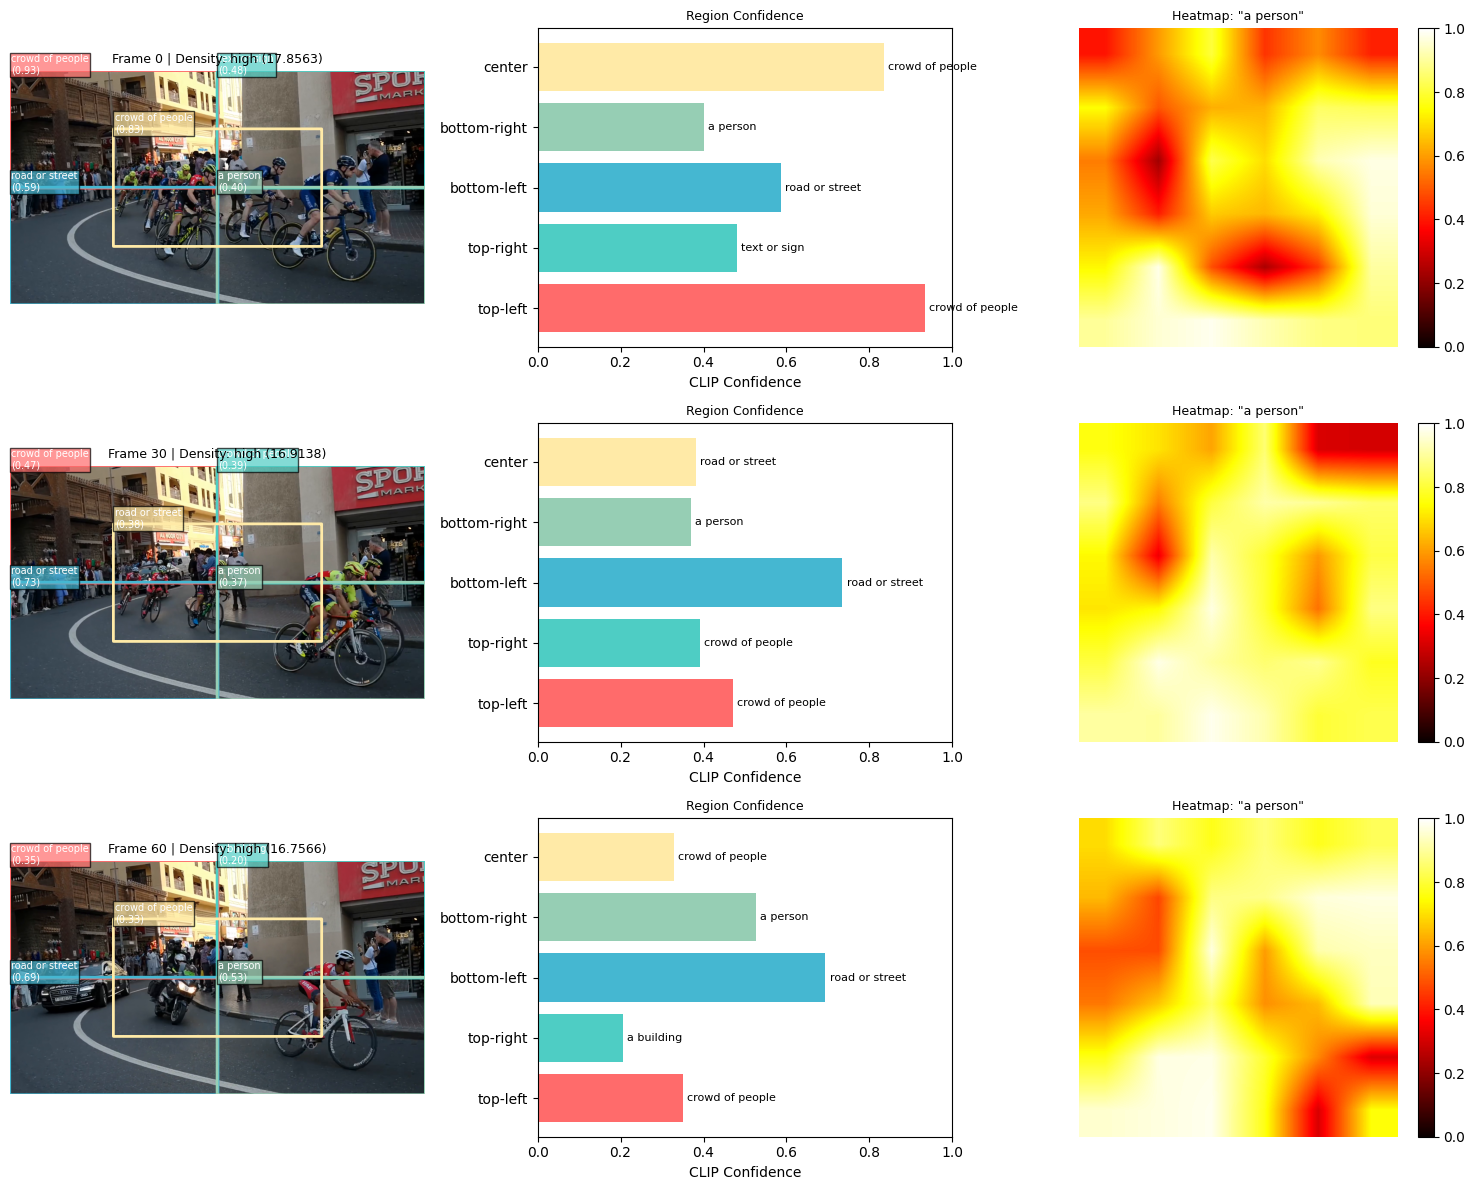

Saved: spatial_analysis.png


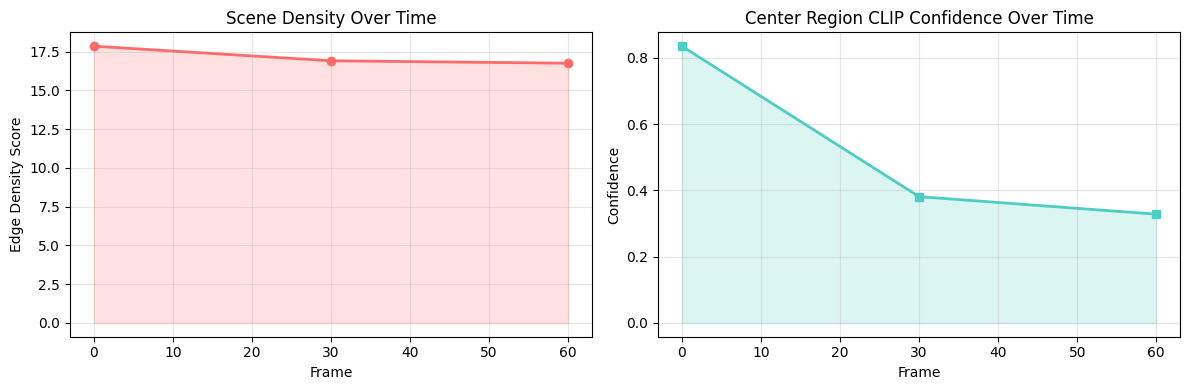

Saved: temporal_trend.png

Spatial Analysis Complete!


In [12]:
# ==============================================
# Part 4: Spatial Analysis App
# ==============================================
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from collections import defaultdict

# ---------- 空間區域定義 ----------
REGIONS = {
    "top-left":     (0.0, 0.0, 0.5, 0.5),
    "top-right":    (0.5, 0.0, 1.0, 0.5),
    "bottom-left":  (0.0, 0.5, 0.5, 1.0),
    "bottom-right": (0.5, 0.5, 1.0, 1.0),
    "center":       (0.25, 0.25, 0.75, 0.75),
}

SPATIAL_LABELS = [
    "a person", "a car", "a building", "nature scenery",
    "an animal", "food", "text or sign", "furniture",
    "water or ocean", "sky", "road or street", "crowd of people",
]

# ---------- 區域裁切 + CLIP 分析 ----------
def analyze_region(pil_img, region_box):
    w, h = pil_img.size
    x1, y1, x2, y2 = (
        int(region_box[0] * w), int(region_box[1] * h),
        int(region_box[2] * w), int(region_box[3] * h),
    )
    crop = pil_img.crop((x1, y1, x2, y2))
    texts = [f"a photo of {l}" for l in SPATIAL_LABELS]
    inputs = clip_processor(images=crop, text=texts, return_tensors="pt", padding=True).to(device)
    with torch.no_grad():
        out = clip_model(**inputs)
        logits = out.logits_per_image
    probs = logits.softmax(dim=-1)[0]
    top_idx = probs.argmax().item()
    return SPATIAL_LABELS[top_idx], probs[top_idx].item()

# ---------- 單幀完整空間分析 ----------
def spatial_analysis_frame(pil_img):
    results = {}
    for region_name, box in REGIONS.items():
        label, conf = analyze_region(pil_img, box)
        results[region_name] = {"label": label, "confidence": round(conf, 3)}
    return results

# ---------- CLIP 熱力圖（sliding window） ----------
def generate_clip_heatmap(pil_img, target_label, grid=6):
    w, h = pil_img.size
    heatmap = np.zeros((grid, grid))
    texts = [f"a photo of {target_label}", "something else"]
    sw, sh = w // grid, h // grid

    for row in range(grid):
        for col in range(grid):
            x1, y1 = col * sw, row * sh
            x2, y2 = min(x1 + sw * 2, w), min(y1 + sh * 2, h)
            crop = pil_img.crop((x1, y1, x2, y2))
            inp = clip_processor(images=crop, text=texts, return_tensors="pt", padding=True).to(device)
            with torch.no_grad():
                out = clip_model(**inp)
                prob = out.logits_per_image.softmax(dim=-1)[0][0].item()
            heatmap[row, col] = prob

    return heatmap

# ---------- 場景密度（畫面複雜度） ----------
def scene_density(pil_img):
    gray = np.array(pil_img.convert("L"), dtype=np.float32)
    edges = cv2.Canny(np.uint8(gray), 50, 150)
    density = float(edges.sum()) / (gray.shape[0] * gray.shape[1])
    if density > 0.08:
        level = "high"
    elif density > 0.03:
        level = "medium"
    else:
        level = "low"
    return {"density_score": round(density, 4), "level": level}

# ---------- 影片空間分析主函式 ----------
def spatial_analysis_video(video_path, sample_rate=30, max_frames=5):
    cap = cv2.VideoCapture(video_path)
    frames_data = []
    idx = 0
    collected = 0

    while collected < max_frames:
        ret, frame = cap.read()
        if not ret:
            break
        if idx % sample_rate == 0:
            rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            pil = Image.fromarray(rgb)
            spatial = spatial_analysis_frame(pil)
            density = scene_density(pil)
            frames_data.append({
                "frame_id": idx,
                "spatial": spatial,
                "density": density,
                "image": pil,
            })
            collected += 1
        idx += 1
    cap.release()
    return frames_data

# ---------- 視覺化 ----------
def visualize_spatial(frames_data, heatmap_label="a person"):
    n = len(frames_data)
    if n == 0:
        print("No frames to visualize.")
        return

    fig, axes = plt.subplots(n, 3, figsize=(15, 4 * n))
    if n == 1:
        axes = [axes]

    region_colors = {
        "top-left": "#FF6B6B", "top-right": "#4ECDC4",
        "bottom-left": "#45B7D1", "bottom-right": "#96CEB4",
        "center": "#FFEAA7",
    }

    for i, fd in enumerate(frames_data):
        pil = fd["image"]
        w, h = pil.size

        # --- Col 0: 原始幀 + 區域標注 ---
        ax0 = axes[i][0]
        ax0.imshow(pil)
        for rname, box in REGIONS.items():
            x1, y1 = box[0] * w, box[1] * h
            bw, bh = (box[2] - box[0]) * w, (box[3] - box[1]) * h
            rect = mpatches.FancyBboxPatch(
                (x1, y1), bw, bh,
                boxstyle="round,pad=2",
                linewidth=2, edgecolor=region_colors[rname],
                facecolor="none"
            )
            ax0.add_patch(rect)
            label = fd["spatial"][rname]["label"]
            conf = fd["spatial"][rname]["confidence"]
            ax0.text(
                x1 + 4, y1 + 14, f"{label}\n({conf:.2f})",
                fontsize=7, color="white",
                bbox=dict(facecolor=region_colors[rname], alpha=0.7, pad=1)
            )
        density = fd["density"]
        ax0.set_title(
            f"Frame {fd['frame_id']} | "
            f"Density: {density['level']} ({density['density_score']})",
            fontsize=9
        )
        ax0.axis("off")

        # --- Col 1: 空間分佈長條圖 ---
        ax1 = axes[i][1]
        regions = list(fd["spatial"].keys())
        confs = [fd["spatial"][r]["confidence"] for r in regions]
        colors = [region_colors[r] for r in regions]
        bars = ax1.barh(regions, confs, color=colors)
        for bar, r in zip(bars, regions):
            lbl = fd["spatial"][r]["label"]
            ax1.text(
                bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
                lbl, va="center", fontsize=8
            )
        ax1.set_xlim(0, 1.0)
        ax1.set_title("Region Confidence", fontsize=9)
        ax1.set_xlabel("CLIP Confidence")

        # --- Col 2: CLIP 熱力圖 ---
        ax2 = axes[i][2]
        heatmap = generate_clip_heatmap(pil, heatmap_label)
        im = ax2.imshow(heatmap, cmap="hot", interpolation="bilinear", vmin=0, vmax=1)
        plt.colorbar(im, ax=ax2)
        ax2.set_title(f'Heatmap: "{heatmap_label}"', fontsize=9)
        ax2.axis("off")

    plt.tight_layout()
    plt.savefig("spatial_analysis.png", dpi=120, bbox_inches="tight")
    plt.show()
    print("Saved: spatial_analysis.png")

# ---------- 時序趨勢圖 ----------
def plot_temporal_trend(frames_data):
    frame_ids = [fd["frame_id"] for fd in frames_data]
    densities = [fd["density"]["density_score"] for fd in frames_data]
    center_confs = [fd["spatial"]["center"]["confidence"] for fd in frames_data]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(frame_ids, densities, marker="o", color="#FF6B6B", linewidth=2)
    ax1.fill_between(frame_ids, densities, alpha=0.2, color="#FF6B6B")
    ax1.set_title("Scene Density Over Time")
    ax1.set_xlabel("Frame")
    ax1.set_ylabel("Edge Density Score")
    ax1.grid(True, alpha=0.3)

    ax2.plot(frame_ids, center_confs, marker="s", color="#4ECDC4", linewidth=2)
    ax2.fill_between(frame_ids, center_confs, alpha=0.2, color="#4ECDC4")
    ax2.set_title("Center Region CLIP Confidence Over Time")
    ax2.set_xlabel("Frame")
    ax2.set_ylabel("Confidence")
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("temporal_trend.png", dpi=120, bbox_inches="tight")
    plt.show()
    print("Saved: temporal_trend.png")

# ---------- 執行 ----------
print("Running Spatial Analysis...")
spatial_data = spatial_analysis_video(video_path, sample_rate=30, max_frames=3)
visualize_spatial(spatial_data, heatmap_label="a person")
plot_temporal_trend(spatial_data)
print("\nSpatial Analysis Complete!")


---
## Part 5: Multimodal AI Agent with Reasoning

這個 Agent 採用 **ReAct（Reasoning + Acting）** 框架：

```
Thought → Action → Observation → Thought → ... → Final Answer
```

Agent 擁有以下工具（Tools）：
| 工具 | 功能 |
|------|------|
| `moderate_video` | 內容安全審查 |
| `spatial_analysis` | 空間場景分析 |
| `summarize_video` | 影片摘要（Qwen2.5-VL） |
| `describe_frame` | 單幀詳細描述 |
| `count_objects` | 指定物件計數 |

Agent 會根據使用者問題，自動規劃要呼叫哪些工具，並整合結果進行推理，最終給出完整答案。


In [13]:
# ==============================================
# Part 5: Multimodal AI Agent with Reasoning
# ==============================================
import re
import textwrap
from dataclasses import dataclass, field
from typing import Any, Dict, List, Optional

# ── Tool 定義 ────────────────────────────────────────────────────
@dataclass
class Tool:
    name: str
    description: str
    func: Any

# ── 工具實作 ─────────────────────────────────────────────────────

def tool_moderate(video_path: str) -> Dict:
    """對影片進行內容安全審查，回傳 flagged 清單與百分比。"""
    result = moderate_video(video_path)
    return {
        "nsfw_percent": result["percentage"],
        "flagged_count": len(result["flagged"]),
        "explanation": result["explanation"],
        "is_safe": result["percentage"] <= 10,
    }

def tool_spatial(video_path: str) -> Dict:
    """對影片進行空間場景分析，回傳各區域主要物件與密度。"""
    data = spatial_analysis_video(video_path, sample_rate=30, max_frames=2)
    summary = []
    for fd in data:
        regions = {r: v["label"] for r, v in fd["spatial"].items()}
        summary.append({
            "frame_id": fd["frame_id"],
            "regions": regions,
            "density": fd["density"]["level"],
        })
    return {"frames": summary}

def tool_summarize(video_path: str) -> str:
    """用 Qwen2.5-VL 對影片生成摘要。"""
    return summarize_video(video_path)

def tool_describe_frame(video_path: str, frame_idx: int = 0) -> Dict:
    """取出指定幀，用 CLIP 分析其最可能的場景類型。"""
    cap = cv2.VideoCapture(video_path)
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
    ret, frame = cap.read()
    cap.release()
    if not ret:
        return {"error": f"Cannot read frame {frame_idx}"}

    pil = Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    scene_labels = [
        "indoor scene", "outdoor scene", "nature landscape",
        "urban street", "sports event", "cooking scene",
        "interview or talk", "action sequence", "documentary footage",
    ]
    texts = [f"a photo of {l}" for l in scene_labels]
    inputs = clip_processor(images=pil, text=texts, return_tensors="pt", padding=True).to(device)
    with torch.no_grad():
        out = clip_model(**inputs)
        probs = out.logits_per_image.softmax(dim=-1)[0]
    top3 = probs.topk(3)
    return {
        "frame_id": frame_idx,
        "top_scenes": [
            {"scene": scene_labels[idx], "confidence": round(probs[idx].item(), 3)}
            for idx in top3.indices.tolist()
        ],
    }

def tool_count_objects(video_path: str, object_name: str = "a person") -> Dict:
    """統計影片各幀中指定物件出現的信心分數，估計出現頻率。"""
    cap = cv2.VideoCapture(video_path)
    scores = []
    texts = [f"a photo of {object_name}", "a photo of something else"]
    idx = 0
    while True:
        ret, frame = cap.read()
        if not ret or idx > 150:
            break
        if idx % 15 == 0:
            pil = Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
            inp = clip_processor(images=pil, text=texts, return_tensors="pt", padding=True).to(device)
            with torch.no_grad():
                out = clip_model(**inp)
                prob = out.logits_per_image.softmax(dim=-1)[0][0].item()
            scores.append(prob)
        idx += 1
    cap.release()
    avg = round(float(np.mean(scores)), 3) if scores else 0.0
    return {
        "object": object_name,
        "avg_confidence": avg,
        "frames_checked": len(scores),
        "likely_present": avg > 0.55,
    }

# ── Tool 註冊表 ───────────────────────────────────────────────────
TOOLS = [
    Tool("moderate_video",
         "Check video for unsafe/NSFW content. Args: video_path (str)",
         tool_moderate),
    Tool("spatial_analysis",
         "Analyze spatial layout and scene density of video. Args: video_path (str)",
         tool_spatial),
    Tool("summarize_video",
         "Generate a detailed summary of the video using Qwen2.5-VL. Args: video_path (str)",
         tool_summarize),
    Tool("describe_frame",
         "Describe scene type of a specific frame. Args: video_path (str), frame_idx (int, default=0)",
         tool_describe_frame),
    Tool("count_objects",
         "Estimate presence/frequency of an object in video. Args: video_path (str), object_name (str)",
         tool_count_objects),
]
TOOL_MAP = {t.name: t for t in TOOLS}

# ── ReAct Agent ──────────────────────────────────────────────────
@dataclass
class AgentStep:
    thought: str
    action: Optional[str] = None
    action_input: Optional[Dict] = None
    observation: Optional[Any] = None
    final_answer: Optional[str] = None

class MultimodalAgent:
    """
    ReAct-style multimodal agent.
    Uses Qwen2.5-VL as the reasoning backbone (via summarize),
    and routes tool calls based on keyword matching + rule-based planning.
    """

    def __init__(self, video_path: str, max_steps: int = 5):
        self.video_path = video_path
        self.max_steps = max_steps
        self.history: List[AgentStep] = []

    # ── 規劃：根據問題決定要用哪些工具 ──
    def _plan_tools(self, question: str) -> List[str]:
        q = question.lower()
        plan = []

        # 安全/內容審查
        if any(k in q for k in ["safe", "nsfw", "appropriate", "moderate", "content", "安全", "審查"]):
            plan.append("moderate_video")

        # 空間分析
        if any(k in q for k in ["where", "location", "spatial", "scene", "layout", "space", "位置", "空間", "場景"]):
            plan.append("spatial_analysis")

        # 物件計數
        object_keywords = {
            "person": "a person", "people": "a person", "human": "a person",
            "car": "a car", "vehicle": "a car",
            "animal": "an animal", "dog": "an animal", "cat": "an animal",
            "building": "a building", "text": "text or sign",
        }
        for kw, obj in object_keywords.items():
            if kw in q:
                plan.append(("count_objects", obj))
                break

        # 場景描述
        if any(k in q for k in ["describe", "what is", "what's in", "scene", "frame", "描述", "是什麼"]):
            plan.append("describe_frame")

        # 摘要（最後一步，或明確要求）
        if any(k in q for k in ["summary", "summarize", "overview", "摘要", "總結"]) or len(plan) == 0:
            plan.append("summarize_video")

        # 去重，保持順序
        seen = set()
        unique_plan = []
        for p in plan:
            key = p if isinstance(p, str) else p[0]
            if key not in seen:
                seen.add(key)
                unique_plan.append(p)
        return unique_plan

    # ── 執行單一工具 ──
    def _execute_tool(self, tool_spec) -> Any:
        if isinstance(tool_spec, tuple):
            tool_name, extra_arg = tool_spec
            tool = TOOL_MAP[tool_name]
            return tool.func(self.video_path, extra_arg)
        else:
            tool = TOOL_MAP[tool_spec]
            return tool.func(self.video_path)

    # ── 推理：整合所有觀察，生成最終答案 ──
    def _reason(self, question: str, observations: List[Dict]) -> str:
        lines = [f'Question: "{question}"', "", "Observations from tools:"]
        for obs in observations:
            lines.append(f"\n[{obs['tool']}]")
            lines.append(str(obs['result']))

        lines += [
            "",
            "Based on the above observations, provide a comprehensive answer.",
            "Integrate findings from all tools and highlight key insights.",
        ]

        # 用 Qwen 做最終推理整合
        from pathlib import Path
        model, processor = load_qwen()
        prompt = "\n".join(lines)
        vpath = Path(self.video_path).resolve()
        messages = [{
            "role": "user",
            "content": [
                {"type": "video", "video": f"file://{vpath}"},
                {"type": "text", "text": prompt},
            ]
        }]
        text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        from qwen_vl_utils import process_vision_info
        image_inputs, video_inputs = process_vision_info(messages)
        inputs = processor(
            text=[text], images=image_inputs, videos=video_inputs,
            return_tensors="pt"
        ).to(model.device)
        with torch.no_grad():
            output_ids = model.generate(**inputs, max_new_tokens=512)
        trimmed = [out[len(inp):] for inp, out in zip(inputs.input_ids, output_ids)]
        return processor.batch_decode(trimmed, skip_special_tokens=True)[0]

    # ── 主執行流程 ──
    def run(self, question: str) -> str:
        print(f"\n{'='*60}")
        print(f"🤖 Agent Question: {question}")
        print(f"{'='*60}")

        plan = self._plan_tools(question)
        observations = []

        for step_i, tool_spec in enumerate(plan[:self.max_steps]):
            tool_name = tool_spec if isinstance(tool_spec, str) else tool_spec[0]
            tool = TOOL_MAP[tool_name]

            # Thought
            thought = f"I need to use [{tool_name}] to answer: {tool.description}"
            print(f"\n💭 Thought {step_i+1}: {thought}")

            # Action
            print(f"🔧 Action: {tool_name}")
            try:
                result = self._execute_tool(tool_spec)
                print(f"👁  Observation: {str(result)[:300]}..." if len(str(result)) > 300 else f"👁  Observation: {result}")
            except Exception as e:
                result = {"error": str(e)}
                print(f"❌ Error: {e}")

            observations.append({"tool": tool_name, "result": result})
            self.history.append(AgentStep(
                thought=thought,
                action=tool_name,
                action_input={"video_path": self.video_path},
                observation=result,
            ))

        # Final Reasoning
        print(f"\n🧠 Final Reasoning (Qwen2.5-VL)...")
        final_answer = self._reason(question, observations)

        step = AgentStep(
            thought="Synthesizing all observations into a final answer.",
            final_answer=final_answer,
        )
        self.history.append(step)

        print(f"\n✅ Final Answer:")
        print(textwrap.fill(final_answer, width=80))
        return final_answer

    def show_trace(self):
        """印出完整的 ReAct 推理鏈。"""
        print("\n" + "="*60)
        print("📋 Agent Reasoning Trace")
        print("="*60)
        for i, step in enumerate(self.history):
            print(f"\n--- Step {i+1} ---")
            print(f"Thought: {step.thought}")
            if step.action:
                print(f"Action: {step.action}")
                print(f"Observation: {str(step.observation)[:200]}")
            if step.final_answer:
                print(f"Final Answer: {step.final_answer[:300]}")


### 執行 Agent

可以問各種問題，Agent 會自動規劃工具並推理整合：


In [14]:
# 建立 Agent
agent = MultimodalAgent(video_path=video_path)

# ── 範例問題 1：綜合分析 ──
answer1 = agent.run(
    "Is this video safe to publish? What is the main scene and where are people located?"
)

# ── 範例問題 2：物件 + 場景 ──
answer2 = agent.run(
    "Are there people in this video? Describe the spatial layout of the scene."
)

# ── 印出完整推理鏈 ──
agent.show_trace()



🤖 Agent Question: Is this video safe to publish? What is the main scene and where are people located?

💭 Thought 1: I need to use [moderate_video] to answer: Check video for unsafe/NSFW content. Args: video_path (str)
🔧 Action: moderate_video
👁  Observation: {'nsfw_percent': 0.0, 'flagged_count': 0, 'explanation': 'No issues detected.', 'is_safe': True}

💭 Thought 2: I need to use [spatial_analysis] to answer: Analyze spatial layout and scene density of video. Args: video_path (str)
🔧 Action: spatial_analysis
👁  Observation: {'frames': [{'frame_id': 0, 'regions': {'top-left': 'crowd of people', 'top-right': 'text or sign', 'bottom-left': 'road or street', 'bottom-right': 'a person', 'center': 'crowd of people'}, 'density': 'high'}, {'frame_id': 30, 'regions': {'top-left': 'crowd of people', 'top-right': 'crowd of people...

💭 Thought 3: I need to use [count_objects] to answer: Estimate presence/frequency of an object in video. Args: video_path (str), object_name (str)
🔧 Action: count_

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]


✅ Final Answer:
The video appears to be safe to publish. The main scene is a sports event,
specifically a cycling race, taking place in an urban setting with spectators
lining the streets. People are located along the sides of the road, watching the
cyclists as they pass by. The environment suggests a competitive atmosphere
typical of professional cycling races.

🤖 Agent Question: Are there people in this video? Describe the spatial layout of the scene.

💭 Thought 1: I need to use [spatial_analysis] to answer: Analyze spatial layout and scene density of video. Args: video_path (str)
🔧 Action: spatial_analysis
👁  Observation: {'frames': [{'frame_id': 0, 'regions': {'top-left': 'crowd of people', 'top-right': 'text or sign', 'bottom-left': 'road or street', 'bottom-right': 'a person', 'center': 'crowd of people'}, 'density': 'high'}, {'frame_id': 30, 'regions': {'top-left': 'crowd of people', 'top-right': 'crowd of people...

💭 Thought 2: I need to use [count_objects] to answer: Estimat

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]


✅ Final Answer:
The video depicts a dynamic scene of a cycling race taking place on a city
street. The cyclists are tightly packed together, indicating a competitive and
intense moment in the race. The road is lined with spectators who are watching
the event intently. Some spectators are standing on the sidewalk, while others
are seated on benches or chairs. The buildings lining the street have various
signs and advertisements, adding to the urban atmosphere.  The cyclists are
wearing professional cycling gear, including helmets and specialized jerseys,
which suggests that this is a professional or semi-professional race. The
presence of a car with an Audi logo in the background further supports the idea
that this is a high-profile event. The overall scene is bustling with activity,
capturing the excitement and intensity of the race.

📋 Agent Reasoning Trace

--- Step 1 ---
Thought: I need to use [moderate_video] to answer: Check video for unsafe/NSFW content. Args: video_path (str)
A

---
## Part 6: Interactive Gradio Application

整合所有功能的互動式介面，包含兩個分頁：

- **🎬 Video Analysis**：上傳影片，一鍵執行內容審查、空間分析、影片摘要，並產生視覺化圖表
- **🤖 ReAct Agent**：輸入任意問題，Agent 自動規劃工具鏈、推理並給出建議


In [15]:
!pip install gradio --quiet


In [16]:
# ==============================================
# Part 6: Interactive Urban Spatial Intelligence App
# ==============================================
import gradio as gr
import tempfile, os, textwrap
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import numpy as np
from PIL import Image
from pathlib import Path
from qwen_vl_utils import process_vision_info

# ════════════════════════════════════════════════════════
# 都市空間分析擴充標籤
# ════════════════════════════════════════════════════════
URBAN_LABELS = [
    "pedestrian walkway", "bicycle lane", "green space or park",
    "street furniture", "building facade", "public plaza",
    "road or vehicle lane", "parking area", "water feature",
    "street lighting", "commercial signage", "construction site",
    "crowd of people", "public transit stop", "outdoor seating",
    "tree canopy", "crosswalk", "street vendor",
]

URBAN_INTERVENTION_RULES = {
    "pedestrian walkway": "✅ 步行空間良好，可考慮增加座椅與遮蔭設施提升舒適度。",
    "bicycle lane": "🚲 已有自行車道，建議加強與步行區的物理分隔及標示。",
    "green space or park": "🌿 綠地比例良好，可評估增設兒童遊戲設施或社區菜園。",
    "street furniture": "🪑 街道傢俱存在，建議定期維護並評估密度是否足夠。",
    "building facade": "🏢 建築立面需評估，可考慮垂直綠化或藝術裝置活化。",
    "public plaza": "🏛️ 公共廣場空間，建議加強活動程式設計與臨時性裝置吸引人潮。",
    "road or vehicle lane": "🚗 車行空間比例偏高，建議評估道路瘦身（Road Diet）或增設人行道。",
    "parking area": "🅿️ 停車場用地，具備改建為臨時公共空間或停車場改造（Parklet）的潛力。",
    "water feature": "💧 水景元素存在，可強化親水步道與生態廊道設計。",
    "street lighting": "💡 照明設施存在，建議評估夜間安全性與智慧照明升級可行性。",
    "commercial signage": "🏪 商業招牌密集，建議制定街道景觀管理規範統一視覺品質。",
    "construction site": "🏗️ 施工中區域，建議規劃臨時行人動線並設置施工說明告示板。",
    "crowd of people": "👥 人潮聚集，顯示空間具活力，可進一步增強公共活動承載能力。",
    "public transit stop": "🚌 大眾運輸站點，建議改善候車環境、遮雨設施與無障礙通道。",
    "outdoor seating": "☕ 戶外座位區存在，可評估增設更多非消費性休憩空間。",
    "tree canopy": "🌳 樹冠層良好，建議延伸行道樹種植計劃並評估熱島效應緩解成效。",
    "crosswalk": "🚶 斑馬線存在，建議評估行人等候時間與號誌時序優化。",
    "street vendor": "🛒 街頭攤販活動，建議提供合法擺攤空間設計以活化街道經濟。",
}

# ════════════════════════════════════════════════════════
# 都市空間元素偵測
# ════════════════════════════════════════════════════════
def detect_urban_elements(pil_img, top_k=6):
    """用 CLIP 偵測影像中的都市空間元素，回傳 top-k 結果。"""
    texts = [f"a photo of {l}" for l in URBAN_LABELS]
    inputs = clip_processor(
        images=pil_img, text=texts,
        return_tensors="pt", padding=True
    ).to(device)
    with torch.no_grad():
        out = clip_model(**inputs)
        probs = out.logits_per_image.softmax(dim=-1)[0]
    topk = probs.topk(top_k)
    return [
        {"element": URBAN_LABELS[i], "confidence": round(probs[i].item(), 3)}
        for i in topk.indices.tolist()
    ]

def generate_intervention_suggestions(urban_elements):
    """根據偵測到的都市元素生成空間介入建議。"""
    suggestions = []
    for el in urban_elements:
        if el["confidence"] > 0.08 and el["element"] in URBAN_INTERVENTION_RULES:
            suggestions.append(URBAN_INTERVENTION_RULES[el["element"]])
    return suggestions if suggestions else ["⚠️ 無法識別明確都市元素，建議上傳更清晰的街道或都市空間影片。"]

# ════════════════════════════════════════════════════════
# 完整都市空間分析（單幀）
# ════════════════════════════════════════════════════════
def full_urban_analysis_frame(pil_img):
    spatial = spatial_analysis_frame(pil_img)
    urban = detect_urban_elements(pil_img)
    density = scene_density(pil_img)
    suggestions = generate_intervention_suggestions(urban)
    return spatial, urban, density, suggestions

# ════════════════════════════════════════════════════════
# 視覺化：都市空間分析儀表板
# ════════════════════════════════════════════════════════
def make_urban_dashboard(frames_data):
    region_colors = {
        "top-left": "#FF6B6B", "top-right": "#4ECDC4",
        "bottom-left": "#45B7D1", "bottom-right": "#96CEB4",
        "center": "#FFEAA7",
    }
    n = len(frames_data)
    fig = plt.figure(figsize=(18, 6 * n))

    for i, fd in enumerate(frames_data):
        pil = fd["image"]
        w, h = pil.size
        urban = detect_urban_elements(pil, top_k=8)
        heatmap = generate_clip_heatmap(pil, urban[0]["element"] if urban else "street")

        gs = gridspec.GridSpec(2, 3, figure=fig,
                               top=1 - i/n + 0.01, bottom=1 - (i+1)/n + 0.04,
                               hspace=0.4, wspace=0.35)

        # ── Col 0 Row 0: 原始幀 + 區域標注 ──
        ax0 = fig.add_subplot(gs[0, 0])
        ax0.imshow(pil)
        for rname, box in REGIONS.items():
            x1, y1 = box[0]*w, box[1]*h
            bw, bh = (box[2]-box[0])*w, (box[3]-box[1])*h
            rect = mpatches.FancyBboxPatch(
                (x1, y1), bw, bh, boxstyle="round,pad=2",
                linewidth=2, edgecolor=region_colors[rname], facecolor="none"
            )
            ax0.add_patch(rect)
            lbl = fd["spatial"][rname]["label"]
            ax0.text(x1+4, y1+14, lbl, fontsize=6.5, color="white",
                     bbox=dict(facecolor=region_colors[rname], alpha=0.75, pad=1))
        ax0.set_title(f"Frame {fd['frame_id']} | Density: {fd['density']['level']}", fontsize=9)
        ax0.axis("off")

        # ── Col 1 Row 0: 都市元素水平條圖 ──
        ax1 = fig.add_subplot(gs[0, 1])
        labels_u = [e["element"] for e in urban]
        confs_u = [e["confidence"] for e in urban]
        cmap = plt.cm.get_cmap("viridis", len(labels_u))
        bars = ax1.barh(labels_u, confs_u, color=[cmap(j) for j in range(len(labels_u))])
        for bar, c in zip(bars, confs_u):
            ax1.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
                     f"{c:.2f}", va="center", fontsize=7.5)
        ax1.set_xlim(0, max(confs_u) * 1.3)
        ax1.set_title("🏙️ Urban Elements (CLIP)", fontsize=9)
        ax1.tick_params(axis='y', labelsize=7.5)

        # ── Col 2 Row 0: CLIP 熱力圖 ──
        ax2 = fig.add_subplot(gs[0, 2])
        im = ax2.imshow(heatmap, cmap="hot", interpolation="bilinear", vmin=0, vmax=1)
        plt.colorbar(im, ax=ax2, fraction=0.046)
        top_el = urban[0]["element"] if urban else "urban"
        ax2.set_title(f'🔥 Heatmap: "{top_el}"', fontsize=9)
        ax2.axis("off")

        # ── Row 1 span: 空間介入建議 ──
        ax3 = fig.add_subplot(gs[1, :])
        ax3.axis("off")
        suggestions = generate_intervention_suggestions(urban)
        suggestion_text = "\n".join([f"• {s}" for s in suggestions[:5]])
        ax3.text(0.01, 0.95, "🏗️ Urban Spatial Intervention Suggestions",
                 transform=ax3.transAxes, fontsize=10, fontweight="bold",
                 va="top", color="#2C3E50")
        ax3.text(0.01, 0.78, suggestion_text,
                 transform=ax3.transAxes, fontsize=8.5, va="top",
                 color="#34495E", linespacing=1.8,
                 bbox=dict(boxstyle="round,pad=0.5", facecolor="#EBF5FB", alpha=0.8))

    fig.suptitle("Urban Spatial Intelligence Dashboard", fontsize=13, fontweight="bold", y=1.01)
    fig.tight_layout()
    return fig

# ════════════════════════════════════════════════════════
# Qwen 影片對話（Video Chat）
# ════════════════════════════════════════════════════════
_qwen_model_cache = {}

def get_qwen():
    """快取 Qwen，避免每次重新載入。"""
    if "model" not in _qwen_model_cache:
        model, processor = load_qwen()
        _qwen_model_cache["model"] = model
        _qwen_model_cache["processor"] = processor
    return _qwen_model_cache["model"], _qwen_model_cache["processor"]

def chat_with_video(video_path, question, history):
    """
    與影片進行多輪對話。
    history 格式：[(user_msg, assistant_msg), ...]
    """
    history = history or []
    if not video_path or not os.path.exists(video_path):
        history.append((question, "⚠️ 請先上傳影片！"))
        return history, ""
    if not question.strip():
        return history, ""

    try:
        model, processor = get_qwen()
        vpath = Path(video_path).resolve()

        # 建構多輪對話 messages
        messages = []

        # 第一輪帶影片
        if len(history) == 0:
            messages.append({
                "role": "user",
                "content": [
                    {"type": "video", "video": f"file://{vpath}"},
                    {"type": "text", "text": question},
                ]
            })
        else:
            # 後續輪次：先放影片 + 歷史對話，再加新問題
            messages.append({
                "role": "user",
                "content": [
                    {"type": "video", "video": f"file://{vpath}"},
                    {"type": "text", "text": history[0][0]},
                ]
            })
            messages.append({"role": "assistant", "content": history[0][1]})
            for user_msg, assistant_msg in history[1:]:
                messages.append({"role": "user", "content": user_msg})
                messages.append({"role": "assistant", "content": assistant_msg})
            messages.append({"role": "user", "content": question})

        text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        image_inputs, video_inputs = process_vision_info(messages)
        inputs = processor(
            text=[text], images=image_inputs, videos=video_inputs,
            return_tensors="pt"
        ).to(model.device)

        with torch.no_grad():
            output_ids = model.generate(**inputs, max_new_tokens=400)
        trimmed = [out[len(inp):] for inp, out in zip(inputs.input_ids, output_ids)]
        answer = processor.batch_decode(trimmed, skip_special_tokens=True)[0]

        history.append((question, answer))
        return history, ""

    except Exception as e:
        history.append((question, f"❌ Error: {e}"))
        return history, ""

# ════════════════════════════════════════════════════════
# Tab 1: 深度空間分析
# ════════════════════════════════════════════════════════
def run_spatial_analysis(video_file):
    if video_file is None:
        return None, "請先上傳影片", ""
    try:
        frames_data = spatial_analysis_video(video_file, sample_rate=30, max_frames=3)
        if not frames_data:
            return None, "無法讀取影片幀", ""

        # 儀表板圖
        fig = make_urban_dashboard(frames_data)
        img_path = tempfile.mktemp(suffix="_urban.png")
        fig.savefig(img_path, dpi=110, bbox_inches="tight")
        plt.close(fig)

        # 文字報告
        report_lines = ["📊 **Urban Spatial Analysis Report**\n"]
        all_suggestions = set()
        for fd in frames_data:
            pil = fd["image"]
            urban = detect_urban_elements(pil, top_k=5)
            report_lines.append(f"**Frame {fd['frame_id']}**")
            report_lines.append(f"Scene Density: {fd['density']['level']} ({fd['density']['density_score']})")
            report_lines.append("Top Urban Elements:")
            for el in urban:
                report_lines.append(f"  • {el['element']} ({el['confidence']:.2f})")
            for s in generate_intervention_suggestions(urban):
                all_suggestions.add(s)
            report_lines.append("")

        report_lines.append("---\n**🏗️ Consolidated Intervention Suggestions:**")
        for s in list(all_suggestions)[:8]:
            report_lines.append(s)

        report_text = "\n".join(report_lines)

        # 時序趨勢圖
        fig_t = _make_trend_figure(frames_data)
        trend_path = tempfile.mktemp(suffix="_trend.png")
        fig_t.savefig(trend_path, dpi=100, bbox_inches="tight")
        plt.close(fig_t)

        return img_path, report_text, trend_path
    except Exception as e:
        return None, f"Error: {e}", None

def _make_trend_figure(frames_data):
    frame_ids = [fd["frame_id"] for fd in frames_data]
    densities = [fd["density"]["density_score"] for fd in frames_data]
    center_confs = [fd["spatial"]["center"]["confidence"] for fd in frames_data]
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(frame_ids, densities, marker="o", color="#FF6B6B", linewidth=2)
    ax1.fill_between(frame_ids, densities, alpha=0.2, color="#FF6B6B")
    ax1.set_title("Scene Density Over Time"); ax1.set_xlabel("Frame")
    ax1.set_ylabel("Edge Density"); ax1.grid(True, alpha=0.3)
    ax2.plot(frame_ids, center_confs, marker="s", color="#4ECDC4", linewidth=2)
    ax2.fill_between(frame_ids, center_confs, alpha=0.2, color="#4ECDC4")
    ax2.set_title("Center Region Confidence Over Time"); ax2.set_xlabel("Frame")
    ax2.set_ylabel("Confidence"); ax2.grid(True, alpha=0.3)
    fig.tight_layout()
    return fig

# ════════════════════════════════════════════════════════
# Tab 3: Urban ReAct Agent（含都市建議）
# ════════════════════════════════════════════════════════
URBAN_QUESTIONS = [
    "這個空間有哪些都市問題？請給出具體的空間介入設計建議。",
    "這條街道對行人友善嗎？有什麼改善建議？",
    "分析這個空間的綠化程度與熱島效應風險，提出改善策略。",
    "這個公共空間的使用率如何？如何通過設計提升人氣？",
    "評估這個區域的交通安全狀況，提出優化方案。",
    "這個場景適合哪種都市再生（Urban Regeneration）策略？",
    "從永續城市（Sustainable City）角度分析這個空間的優缺點。",
    "這個空間有哪些無障礙設計的不足？如何改善？",
]

def run_urban_agent(video_file, question, history):
    history = history or []
    if not video_file or not os.path.exists(video_file):
        history.append((question, "⚠️ 請先上傳影片！"))
        return history, ""
    if not question.strip():
        return history, ""

    try:
        # 1. CLIP 都市元素偵測
        cap = cv2.VideoCapture(video_file)
        ret, frame = cap.read()
        cap.release()
        clip_context = ""
        if ret:
            pil = Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
            urban_els = detect_urban_elements(pil, top_k=6)
            density = scene_density(pil)
            suggestions = generate_intervention_suggestions(urban_els)
            els_text = ", ".join([f"{e['element']}({e['confidence']:.2f})" for e in urban_els])
            clip_context = (
                f"[CLIP Analysis] Urban elements detected: {els_text}. "
                f"Scene density: {density['level']} ({density['density_score']}). "
                f"Initial suggestions: {'; '.join(suggestions[:3])}"
            )

        # 2. 內容審查
        mod = moderate_video(video_file)
        mod_context = f"[Moderation] NSFW: {mod['percentage']}%, Safe: {mod['percentage'] <= 10}"

        # 3. 組合 prompt 給 Qwen
        system_context = (
            "You are an expert urban planner and spatial analyst. "
            "Analyze the video with the following pre-computed data and provide "
            "detailed, actionable urban spatial intervention recommendations.\n"
            f"{clip_context}\n{mod_context}\n"
            "Please respond in the same language as the question. "
            "Structure your answer with: 1) Spatial Observations, "
            "2) Key Issues, 3) Design Recommendations, 4) Priority Actions."
        )
        full_question = f"{system_context}\n\nUser Question: {question}"

        # 4. Qwen 推理
        model, processor = get_qwen()
        vpath = Path(video_file).resolve()
        messages = [{
            "role": "user",
            "content": [
                {"type": "video", "video": f"file://{vpath}"},
                {"type": "text", "text": full_question},
            ]
        }]
        text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        image_inputs, video_inputs = process_vision_info(messages)
        inputs = processor(
            text=[text], images=image_inputs, videos=video_inputs,
            return_tensors="pt"
        ).to(model.device)
        with torch.no_grad():
            output_ids = model.generate(**inputs, max_new_tokens=512)
        trimmed = [out[len(inp):] for inp, out in zip(inputs.input_ids, output_ids)]
        answer = processor.batch_decode(trimmed, skip_special_tokens=True)[0]

        # 5. 建構 trace
        trace = (
            f"**🔍 CLIP Urban Detection:**\n{clip_context}\n\n"
            f"**🛡️ Moderation:**\n{mod_context}\n\n"
            f"**🧠 Qwen2.5-VL Reasoning:** Combined multimodal analysis with "
            f"urban planning expertise → structured recommendations generated."
        )

        history.append((question, answer))
        return history, trace

    except Exception as e:
        history.append((question, f"❌ Error: {e}"))
        return history, str(e)

# ════════════════════════════════════════════════════════
# Gradio UI
# ════════════════════════════════════════════════════════
THEME = gr.themes.Soft(
    primary_hue="violet",
    secondary_hue="cyan",
    font=[gr.themes.GoogleFont("Inter"), "sans-serif"],
)

with gr.Blocks(theme=THEME, title="🏙️ Urban Spatial Intelligence") as demo:

    gr.Markdown(
        """
        # 🏙️ Urban Spatial Intelligence Platform
        **Multimodal AI** for urban space analysis, interaction design & spatial intervention recommendations
        *Powered by CLIP + Qwen2.5-VL*
        """
    )

    with gr.Tabs():

        # ════════════════════════════════════════
        # Tab 1: Deep Spatial Analysis
        # ════════════════════════════════════════
        with gr.Tab("🏙️ Spatial Analysis"):
            gr.Markdown(
                "Upload a video to run **deep urban spatial analysis**: element detection, "
                "density heatmap, region breakdown, and **intervention suggestions**."
            )
            with gr.Row():
                with gr.Column(scale=1):
                    vid_s = gr.Video(label="Upload Video", height=240)
                    spatial_btn = gr.Button("🔍 Analyse Urban Space", variant="primary", size="lg")
                with gr.Column(scale=2):
                    spatial_report = gr.Markdown(label="Analysis Report")

            spatial_dashboard = gr.Image(label="🗺️ Urban Dashboard", type="filepath")
            spatial_trend = gr.Image(label="📈 Temporal Trend", type="filepath")

            spatial_btn.click(
                fn=run_spatial_analysis,
                inputs=[vid_s],
                outputs=[spatial_dashboard, spatial_report, spatial_trend],
            )

        # ════════════════════════════════════════
        # Tab 2: Video Chat
        # ════════════════════════════════════════
        with gr.Tab("💬 Video Chat"):
            gr.Markdown(
                "**Talk directly to the video.** Ask anything about the space, scene, "
                "objects, atmosphere, or design quality. Supports multi-turn conversation."
            )
            with gr.Row():
                with gr.Column(scale=1):
                    vid_c = gr.Video(label="Upload Video", height=220)
                    gr.Markdown("**💡 Suggested Questions:**")
                    chat_suggestions = gr.Dataset(
                        components=[gr.Textbox(visible=False)],
                        samples=[
                            ["這個影片中的空間給你什麼感受？"],
                            ["這個場景是室內還是室外？有哪些主要元素？"],
                            ["這個空間的人流狀況如何？"],
                            ["你看到哪些都市設計的優點或問題？"],
                            ["這個空間的光線與氛圍如何影響使用者體驗？"],
                            ["如果你是都市設計師，你會如何改造這個空間？"],
                        ],
                        label="Click to use",
                    )
                with gr.Column(scale=2):
                    chat_box = gr.Chatbot(
                        label="Video Conversation (Qwen2.5-VL)",
                        height=380,
                        bubble_full_width=False,
                        avatar_images=(None, "https://huggingface.co/front/assets/huggingface_logo-noborder.svg"),
                    )
                    with gr.Row():
                        chat_input = gr.Textbox(
                            placeholder="問任何關於這個影片空間的問題...",
                            label="", scale=4, lines=2,
                        )
                        chat_send = gr.Button("Send 💬", variant="primary", scale=1)
                    chat_clear = gr.Button("🗑️ Clear", variant="stop", size="sm")

            # 點選建議問題自動填入
            chat_suggestions.click(
                fn=lambda x: x[0],
                inputs=[chat_suggestions],
                outputs=[chat_input],
            )
            chat_send.click(
                fn=chat_with_video,
                inputs=[vid_c, chat_input, chat_box],
                outputs=[chat_box, chat_input],
            )
            chat_input.submit(
                fn=chat_with_video,
                inputs=[vid_c, chat_input, chat_box],
                outputs=[chat_box, chat_input],
            )
            chat_clear.click(fn=lambda: ([], ""), outputs=[chat_box, chat_input])

        # ════════════════════════════════════════
        # Tab 3: Urban Agent
        # ════════════════════════════════════════
        with gr.Tab("🤖 Urban Agent"):
            gr.Markdown(
                "The **Urban Spatial Agent** combines CLIP detection + moderation + "
                "Qwen2.5-VL reasoning to give you **structured urban design recommendations**. "
                "Ask in any language."
            )
            with gr.Row():
                with gr.Column(scale=1):
                    vid_a = gr.Video(label="Upload Video", height=220)
                    gr.Markdown("**🏗️ Urban Design Questions:**")
                    for q in URBAN_QUESTIONS[:4]:
                        gr.Markdown(f"› *{q}*")
                    agent_suggestions = gr.Dropdown(
                        choices=URBAN_QUESTIONS,
                        label="Quick Question Templates",
                        interactive=True,
                    )

                with gr.Column(scale=2):
                    agent_chat = gr.Chatbot(
                        label="Urban Agent Conversation",
                        height=360,
                        bubble_full_width=False,
                    )
                    with gr.Row():
                        agent_input = gr.Textbox(
                            placeholder="詢問都市空間分析與介入建議...",
                            label="", scale=4, lines=2,
                        )
                        agent_send = gr.Button("Ask Agent 🤖", variant="primary", scale=1)
                    agent_clear = gr.Button("🗑️ Clear", variant="stop", size="sm")

            with gr.Accordion("🔍 Multimodal Reasoning Trace (CLIP + Qwen)", open=False):
                agent_trace = gr.Markdown()

            # 下拉選單自動填入問題
            agent_suggestions.change(
                fn=lambda x: x,
                inputs=[agent_suggestions],
                outputs=[agent_input],
            )
            agent_send.click(
                fn=run_urban_agent,
                inputs=[vid_a, agent_input, agent_chat],
                outputs=[agent_chat, agent_trace],
            )
            agent_input.submit(
                fn=run_urban_agent,
                inputs=[vid_a, agent_input, agent_chat],
                outputs=[agent_chat, agent_trace],
            )
            agent_clear.click(fn=lambda: ([], ""), outputs=[agent_chat, agent_trace])

    gr.Markdown(
        """
        ---
        🔧 **Models**: CLIP `openai/clip-vit-base-patch32` · Qwen `Qwen2.5-VL-3B-Instruct`
        &nbsp;|&nbsp; 🏙️ **Urban Labels**: 18 spatial element categories
        &nbsp;|&nbsp; 🗺️ **Regions**: 5 spatial zones per frame
        """
    )

demo.launch(share=True, debug=False)

/tmp/ipykernel_40053/2385142350.py:403: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=THEME, title="🏙️ Urban Spatial Intelligence") as demo:
/tmp/ipykernel_40053/2385142350.py:464: UserWarning: You have not specified a value for the `type` parameter. Defaulting to the 'tuples' format for chatbot messages, but this is deprecated and will be removed in a future version of Gradio. Please set type='messages' instead, which uses openai-style dictionaries with 'role' and 'content' keys.
  chat_box = gr.Chatbot(
/tmp/ipykernel_40053/2385142350.py:464: DeprecationWarning: The 'bubble_full_width' parameter will be removed in Gradio 6.0. This parameter no longer has any effect.
  chat_box = gr.Chatbot(
/tmp/ipykernel_40053/2385142350.py:464: DeprecationWarning: The default value of 'allow_tags' in gr.Chatbot will be changed from False to True in Gradio 6.0. You wi

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://870c602d3123fbedde.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
